In [ ]:
#librerias necesarias para crear el modelo de CNN
import tensorflow as tf

from tensorflow.keras.datasets import mnist
from tensorflow.python.keras.utils import np_utils

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout, Dense
from tensorflow.keras import backend as K

In [ ]:
#librerias necesarias para graficar
import numpy as np
import matplotlib.pyplot as plt
import mlxtend
import itertools
from sklearn.metrics import confusion_matrix

In [ ]:
K.clear_session()

In [ ]:
(x_train, y_train), (x_test, y_test) = mnist.load_data() #cargamos el dataset Mnist
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

11490434/11490434 [==============================] - 0s 0us/step
(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


In [ ]:
#reajustamos las imagenes de entrenamiento y validacion para pasarlas al modelo
#x_train = x_train.reshape(60000,784)
#x_test = x_test.reshape(10000,784)
x_train = np.reshape( x_train, (x_train.shape[0],x_train.shape[1]*x_train.shape[2]) )
x_test = np.reshape( x_test, (x_test.shape[0],x_test.shape[1]*x_test.shape[2]) )

In [ ]:
#normalizamos los datos de entrada a valores entre 0 y 1
x_train = x_train/255.0
x_test = x_test/255.0

In [ ]:
#convertimos las etiquetas del set de entrenamiento y validacion a formato one-hot
nclasses = 10
y_train = np_utils.to_categorical(y_train,nclasses)
y_test = np_utils.to_categorical(y_test,nclasses)

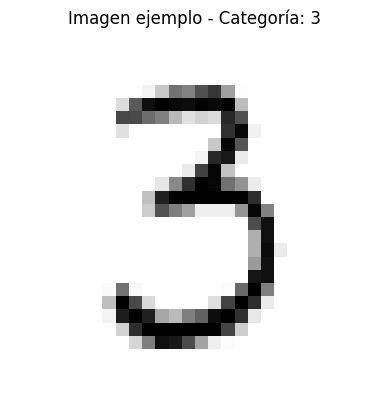

In [ ]:
#mostramos una imagen del set de entrenamiento
nimagen = 50   #500 100
plt.imshow(x_train[nimagen,:].reshape(28,28), cmap='gray_r')
plt.title('Imagen ejemplo - Categoría: ' + str(np.argmax(y_train[nimagen])))
plt.axis('off')
plt.show()

In [ ]:
np.random.seed(1)		# Para reproducibilidad del entrenamiento
input_dim = x_train.shape[1]
output_dim = y_train.shape[1]

# Creamos el modelo
modelo = Sequential()
# CAPA DENSA 1
modelo.add(Dense(32,activation='relu',input_dim=input_dim))
#modelo.add(Dropout(0.3))
# CAPA DENSA 2
modelo.add(Dense(64,activation='relu'))
#modelo.add(Dropout(0.3))
# CAPA DENSA 3
modelo.add(Dense(128,activation='relu'))
#modelo.add(Dropout(0.3))

modelo.add(Dense(output_dim,activation='softmax'))
modelo.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 32)                25120     
                                                                 
 dense_1 (Dense)             (None, 64)                2112      
                                                                 
 dense_2 (Dense)             (None, 128)               8320      
                                                                 
 dense_3 (Dense)             (None, 10)                1290      
                                                                 
Total params: 36842 (143.91 KB)
Trainable params: 36842 (143.91 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [ ]:
# definimos el optimizador a utilizar
#sgd = optimizer=tf.keras.optimizers.SGD(learning_rate=0.001)
from keras.optimizers import SGD
sgd = SGD(learning_rate=0.1)
modelo.compile(loss='categorical_crossentropy', optimizer=sgd, metrics=['accuracy'])


In [ ]:
# entrenamos el modelo
num_epochs = 30
batch_size = 128
#historia = modelo.fit(x_train, y_train, epochs=num_epochs, batch_size=batch_size, verbose=1,validation_split=0.2)
historia = modelo.fit(x_train, y_train, epochs=num_epochs, batch_size=batch_size, verbose=1,validation_data=(x_test,y_test))


Epoch 1/30
469/469 [==============================] - 8s 5ms/step - loss: 0.5711 - accuracy: 0.8215 - val_loss: 0.2552 - val_accuracy: 0.9243
Epoch 2/30
469/469 [==============================] - 2s 4ms/step - loss: 0.2341 - accuracy: 0.9304 - val_loss: 0.2032 - val_accuracy: 0.9392
Epoch 3/30
469/469 [==============================] - 2s 4ms/step - loss: 0.1797 - accuracy: 0.9458 - val_loss: 0.1642 - val_accuracy: 0.9502
Epoch 4/30
469/469 [==============================] - 2s 4ms/step - loss: 0.1486 - accuracy: 0.9552 - val_loss: 0.1534 - val_accuracy: 0.9514
Epoch 5/30
469/469 [==============================] - 2s 4ms/step - loss: 0.1295 - accuracy: 0.9617 - val_loss: 0.1305 - val_accuracy: 0.9594
Epoch 6/30
469/469 [==============================] - 3s 6ms/step - loss: 0.1150 - accuracy: 0.9649 - val_loss: 0.1210 - val_accuracy: 0.9620
Epoch 7/30
469/469 [==============================] - 2s 4ms/step - loss: 0.1020 - accuracy: 0.9688 - val_loss: 0.1170 - val_accuracy: 0.9626
Epoch 

In [ ]:
# guardamos la prediccion de nuestro modelo
y_pred = modelo.predict(x_test)

313/313 [==============================] - 1s 2ms/step


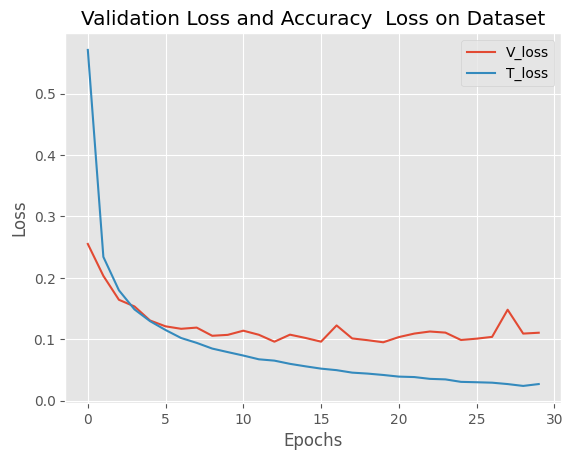

In [ ]:
# grafica de evolucion del error para el set de entrenamiento y validacion
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, num_epochs), historia.history["val_loss"], label="V_loss")
plt.plot(np.arange(0, num_epochs), historia.history["loss"], label="T_loss")
plt.title("Validation Loss and Accuracy  Loss on Dataset")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(loc="best")

In [ ]:
# armamos arreglos para graficar matriz de confusion
y_ref = np.argmax(y_test, axis=1)
y_pred=np.argmax(y_pred, axis=1)
etiquetas = ['0','1','2','3','4','5','6','7','8','9']

In [ ]:
print(y_test.shape)
print(y_pred.shape)

(10000, 10)
(10000,)


In [ ]:
# imprimimos matriz de confusion
matriz= confusion_matrix(y_ref, y_pred)
print(matriz)

[[ 965    0    3    0    1    2    4    2    2    1]
 [   0 1122    5    1    0    1    4    1    1    0]
 [   4    2 1004    6    3    0    2    6    5    0]
 [   2    2    7  973    0    6    0    8    8    4]
 [   1    0    1    0  955    0    8    5    3    9]
 [   4    0    0   10    2  852   10    2    7    5]
 [   2    3    0    0    5    5  940    0    3    0]
 [   1    6   11    1    2    0    1  994    6    6]
 [   9    0    3    3    2    6    9    4  935    3]
 [   2    4    1    5    7    2    3    5    7  973]]


In [ ]:
def plot_matriz(matriz, clases, normalize=False, title='Matriz', cmap=plt.get_cmap('Blues')):
    plt.imshow(matriz, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks=np.arange(len(clases))
    plt.xticks(tick_marks, clases, rotation=45)
    plt.yticks(tick_marks, clases)

    thresh=matriz.max()/2
    for i, j in itertools.product(range(matriz.shape[0]), range(matriz.shape[1])):
        plt.text(j, i, matriz[i,j], horizontalalignment="center", color="white" if matriz[i,j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel("Reales")
    plt.xlabel("Predicciones")

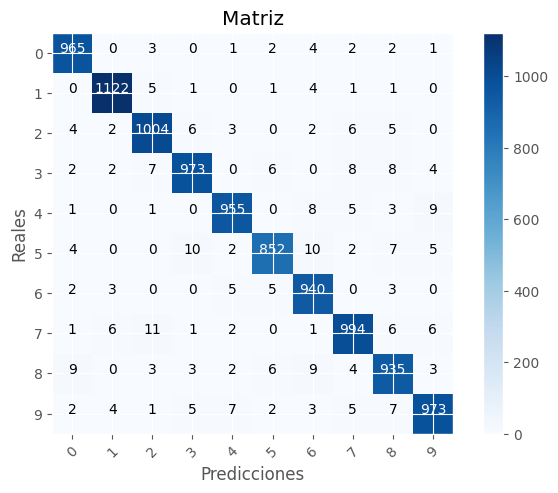

In [ ]:
# matriz de confusion a color
plot_matriz(matriz, etiquetas)